# Task 3 — Customer Churn Prediction (Bank Customers)
### Binary Classification · Random Forest · Feature Importance · One-Hot & Label Encoding

**Objective:** Identify customers who are likely to leave the bank (churn).

**Dataset:** Churn Modelling Dataset — Kaggle

**Skills Covered:**
- Categorical data encoding — Label Encoding and One-Hot Encoding
- Data cleaning and preparation
- Supervised classification modeling using Random Forest
- Feature importance analysis — understanding what drives churn


## Step 1 — Install Required Libraries

We install all libraries needed for this project in one command.

**Libraries used:**
- `pandas` — data manipulation and cleaning
- `numpy` — numerical operations
- `matplotlib` + `seaborn` — data visualization
- `scikit-learn` — encoding, model training, and evaluation

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Step 2 — Import Libraries

All imports are loaded at the top for a clean, organized structure.

**Key imports:**
- `LabelEncoder` — converts binary categories like Gender (Male/Female) to 0/1
- `pd.get_dummies()` — One-Hot Encoding for multi-class categories like Geography
- `RandomForestClassifier` — our main classification model, also provides feature importance
- `StandardScaler` — normalizes numerical features to the same scale before training

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

print('All libraries imported successfully.')

All libraries imported successfully.


## Step 3 — Load the Dataset

Load the Churn Modelling dataset downloaded from Kaggle.
We immediately inspect its shape, column names, and first few rows to understand the structure before doing anything else.

**What to check:**
- How many customers and features exist in the dataset
- What each column represents
- The target column is `Exited` — `1` means the customer left the bank (churned), `0` means they stayed

In [3]:
# Load dataset — make sure Churn_Modelling.csv is in the same folder as this notebook
df = pd.read_csv('Churn_Modelling.csv')

print('Shape:', df.shape)
print('\nColumn Names:')
print(df.columns.tolist())
print('\nFirst 5 Rows:')
df.head()

Shape: (10000, 14)

Column Names:
['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

First 5 Rows:


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Step 4 — Dataset Overview and Data Types

We inspect column data types, non-null counts, and memory usage to understand the full structure.
This step tells us which columns need encoding and confirms there are no hidden nulls.

**Key observations:**
- `RowNumber`, `CustomerId`, and `Surname` are identifiers with zero predictive value
- `Geography` and `Gender` are categorical and will need encoding before modeling
- `Exited` is our **target variable** — binary (0 = stayed, 1 = churned)

In [4]:
print('Dataset Info:')
print('-' * 45)
df.info()

print('\nTarget Variable Distribution (Exited):')
print(df['Exited'].value_counts())
print('\nPercentage:')
print(df['Exited'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

Dataset Info:
---------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB

Target Variable Distribution (Exited):
Exited
0 

## Step 5 — Check for Missing Values and Duplicates

Before cleaning, we check whether the dataset has any missing values or duplicate rows.
This dataset is known to be clean, but we always verify — never assume.

**Why this matters:**
- Missing values cause model training to fail or produce biased predictions
- Duplicate rows cause data leakage — the model might memorize repeated records instead of learning patterns
- If duplicates are found, we drop them to ensure every customer appears exactly once

In [5]:
print('Missing Values per Column:')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values found.')

print(f'\nDuplicate Rows: {df.duplicated().sum()}')

# Drop duplicates if any exist
df.drop_duplicates(inplace=True)

print(f'Dataset shape after cleaning: {df.shape}')

Missing Values per Column:
No missing values found.

Duplicate Rows: 0
Dataset shape after cleaning: (10000, 14)


## Step 6 — Drop Irrelevant Columns

Not every column in the dataset is useful for prediction.
We remove columns that are identifiers or carry no information about customer behavior.

**Why these three columns are dropped:**
- `RowNumber` — just a row index, no customer information
- `CustomerId` — a unique ID, not a behavioral signal
- `Surname` — a customer's last name has no predictive relationship with churn

In [6]:
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True)

print('Remaining columns after dropping identifiers:')
print(df.columns.tolist())
print(f'\nShape: {df.shape}')

Remaining columns after dropping identifiers:
['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

Shape: (10000, 11)


## Step 7 — EDA: Churn Distribution

We visualize the balance of our target variable before anything else.
Class imbalance is one of the most important things to detect early in a classification project.

**What to observe:**
- If the dataset is heavily imbalanced (e.g. 90% stayed, 10% churned), a model could achieve high accuracy by just predicting 'stayed' every time
- The churn rate in banking datasets typically sits between 15% and 25%
- We show both a count chart and a percentage pie chart for a complete picture

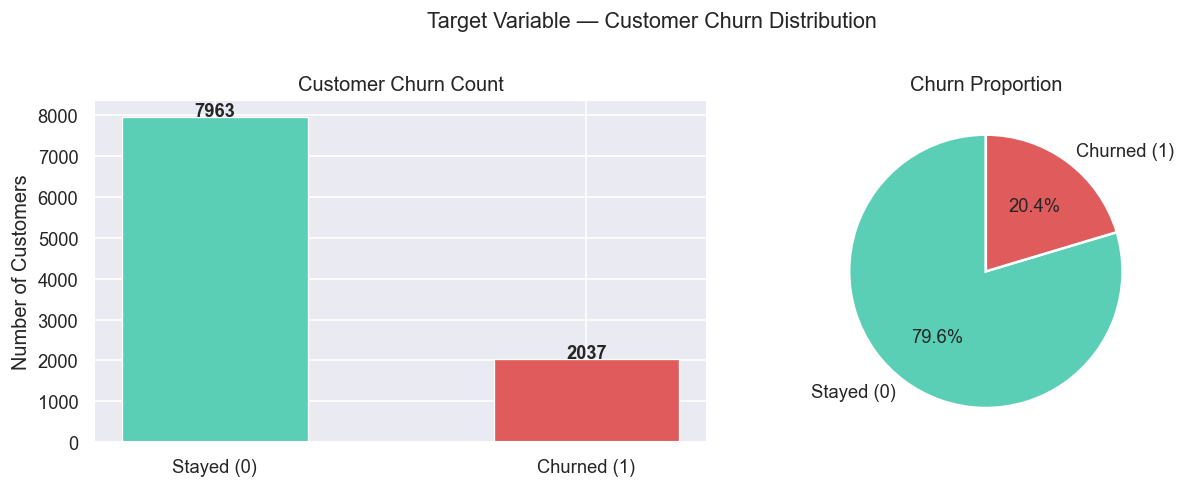

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
counts = df['Exited'].value_counts()
colors = ['#5bcfb5', '#e05c5c']
labels = ['Stayed (0)', 'Churned (1)']

axes[0].bar(labels, counts.values, color=colors,
            edgecolor='white', linewidth=0.8, width=0.5)
for i, val in enumerate(counts.values):
    axes[0].text(i, val + 30, str(val), ha='center', fontweight='bold')
axes[0].set_title('Customer Churn Count')
axes[0].set_ylabel('Number of Customers')

axes[1].pie(counts.values, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[1].set_title('Churn Proportion')

fig.suptitle('Target Variable — Customer Churn Distribution', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Step 8 — EDA: Churn by Geography and Gender

Geography and Gender are the two main categorical features in this dataset.
We compare churn rates across both to find which groups are most at risk.

**What to observe:**
- Do customers from certain countries churn more than others?
- Is there a meaningful difference in churn rate between male and female customers?
- High churn in a specific group suggests that factor is a strong predictor

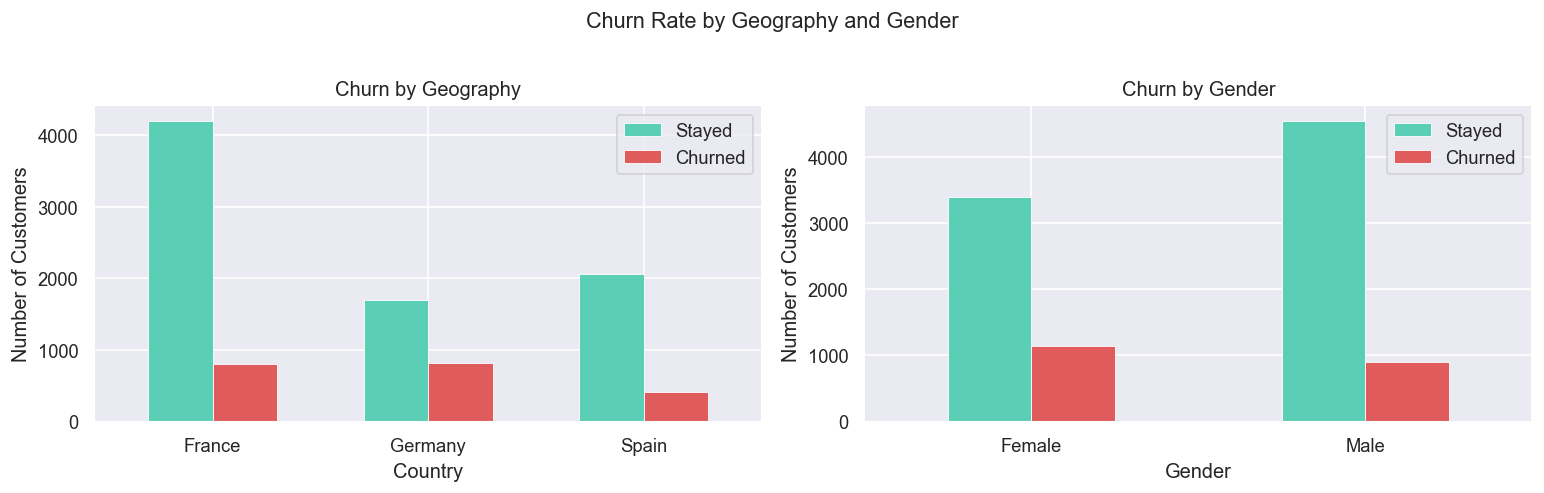

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
palette = {0: '#5bcfb5', 1: '#e05c5c'}

# Geography
geo_churn = pd.crosstab(df['Geography'], df['Exited'])
geo_churn.plot(kind='bar', ax=axes[0],
               color=['#5bcfb5', '#e05c5c'],
               edgecolor='white', linewidth=0.5, width=0.6)
axes[0].set_title('Churn by Geography')
axes[0].set_xlabel('Country')
axes[0].set_ylabel('Number of Customers')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(['Stayed', 'Churned'])

# Gender
gen_churn = pd.crosstab(df['Gender'], df['Exited'])
gen_churn.plot(kind='bar', ax=axes[1],
               color=['#5bcfb5', '#e05c5c'],
               edgecolor='white', linewidth=0.5, width=0.5)
axes[1].set_title('Churn by Gender')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Number of Customers')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(['Stayed', 'Churned'])

fig.suptitle('Churn Rate by Geography and Gender', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Step 9 — EDA: Age, Balance and Estimated Salary

Numerical features like age, balance, and salary can reveal strong churn signals when compared across churned vs retained customers.
We use overlapping histograms so both groups are visible on the same chart.

**What to observe:**
- Older customers may churn more — they may have different banking expectations
- High-balance customers churning is a major business risk — they carry the most value
- If salary distributions look identical for churned and retained, salary may not be a useful feature

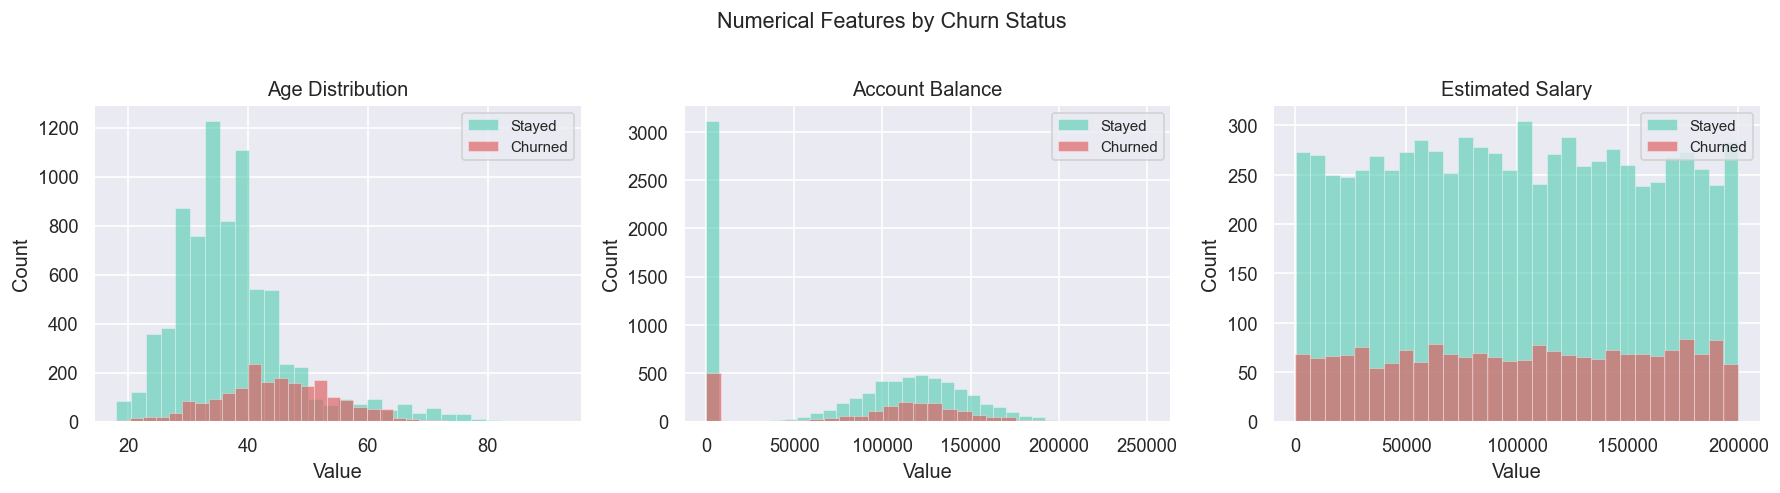

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
features = ['Age', 'Balance', 'EstimatedSalary']
titles   = ['Age Distribution', 'Account Balance', 'Estimated Salary']
palette  = {0: '#5bcfb5', 1: '#e05c5c'}

for ax, feat, title in zip(axes, features, titles):
    for exited, grp in df.groupby('Exited'):
        ax.hist(grp[feat], bins=30, alpha=0.65,
                label='Churned' if exited == 1 else 'Stayed',
                color=palette[exited],
                edgecolor='white', linewidth=0.3)
    ax.set_title(title)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

fig.suptitle('Numerical Features by Churn Status', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Step 10 — EDA: Credit Score, Tenure and Number of Products

We examine three more numerical features that are closely tied to customer engagement and loyalty.
Box plots are ideal here — they show the median, spread, and outliers for each churn group side by side.

**What to observe:**
- `CreditScore` — do customers with lower scores churn more often?
- `Tenure` — do newer or older customers churn more?
- `NumOfProducts` — customers with only one product may have less reason to stay

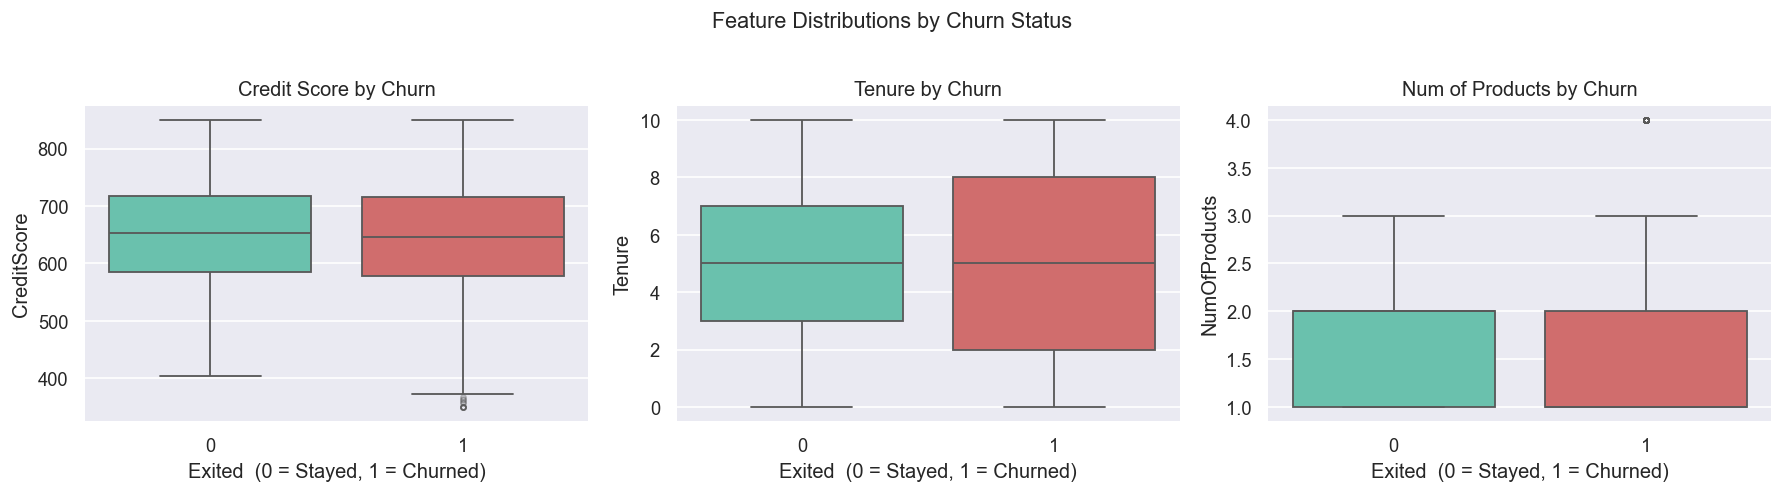

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
features = ['CreditScore', 'Tenure', 'NumOfProducts']
titles   = ['Credit Score by Churn', 'Tenure by Churn', 'Num of Products by Churn']
palette  = {0: '#5bcfb5', 1: '#e05c5c'}

for ax, feat, title in zip(axes, features, titles):
    sns.boxplot(
        data=df, x='Exited', y=feat,
        hue='Exited', palette=palette,
        ax=ax, linewidth=1.1, legend=False,
        flierprops=dict(marker='o', markersize=3, alpha=0.4)
    )
    ax.set_title(title)
    ax.set_xlabel('Exited  (0 = Stayed, 1 = Churned)')
    ax.set_ylabel(feat)

fig.suptitle('Feature Distributions by Churn Status', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Step 11 — EDA: Active Membership and Credit Card Ownership

We analyze two binary behavioral features: whether a customer has a credit card and whether they are an active member.
These features directly reflect customer engagement with the bank.

**What to observe:**
- `HasCrCard` — does owning a credit card reduce churn likelihood?
- `IsActiveMember` — active members are more engaged; we expect them to churn less
- Churn rates within each group are more informative than raw counts

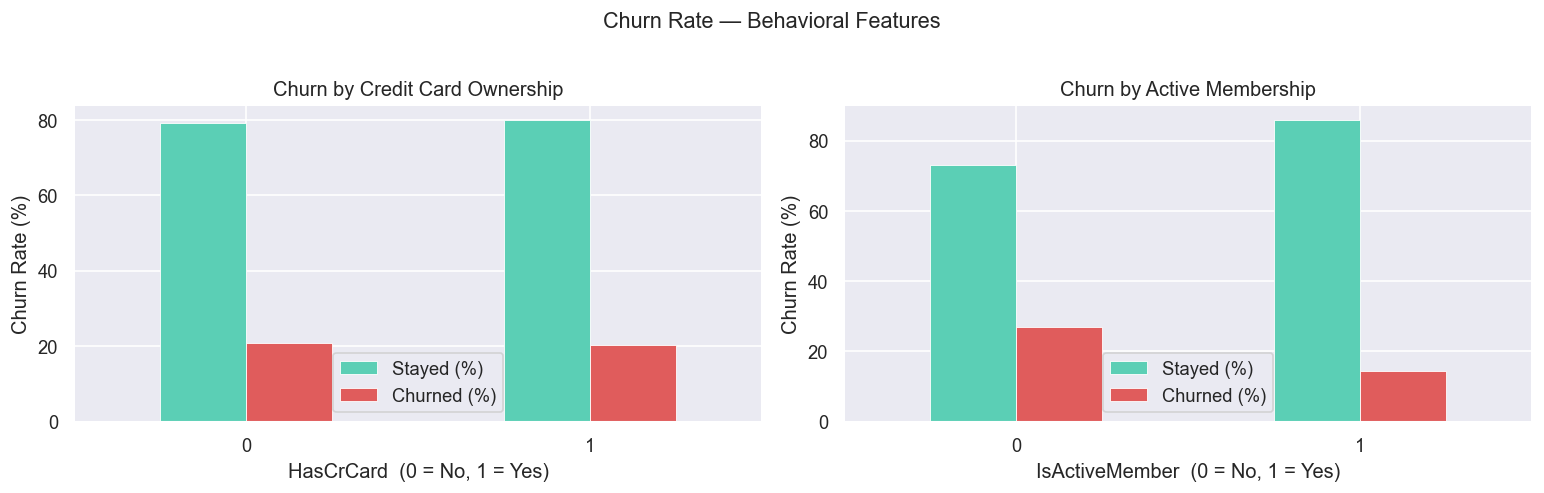

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, feat, title in zip(
    axes,
    ['HasCrCard', 'IsActiveMember'],
    ['Churn by Credit Card Ownership', 'Churn by Active Membership']
):
    ct = pd.crosstab(df[feat], df['Exited'], normalize='index') * 100
    ct.plot(kind='bar', ax=ax,
            color=['#5bcfb5', '#e05c5c'],
            edgecolor='white', linewidth=0.5, width=0.5)
    ax.set_title(title)
    ax.set_xlabel(feat + '  (0 = No, 1 = Yes)')
    ax.set_ylabel('Churn Rate (%)')
    ax.tick_params(axis='x', rotation=0)
    ax.legend(['Stayed (%)', 'Churned (%)'])

fig.suptitle('Churn Rate — Behavioral Features', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Step 12 — EDA: Correlation Heatmap

The correlation heatmap shows the linear relationships between all numerical features and the target.
This helps us identify which features are most correlated with churn before building the model.

**What to observe:**
- Features with higher correlation (positive or negative) to `Exited` are stronger predictors
- Highly correlated input features (multicollinearity) can destabilize some models
- `Age` is expected to show one of the highest correlations with churn in this dataset

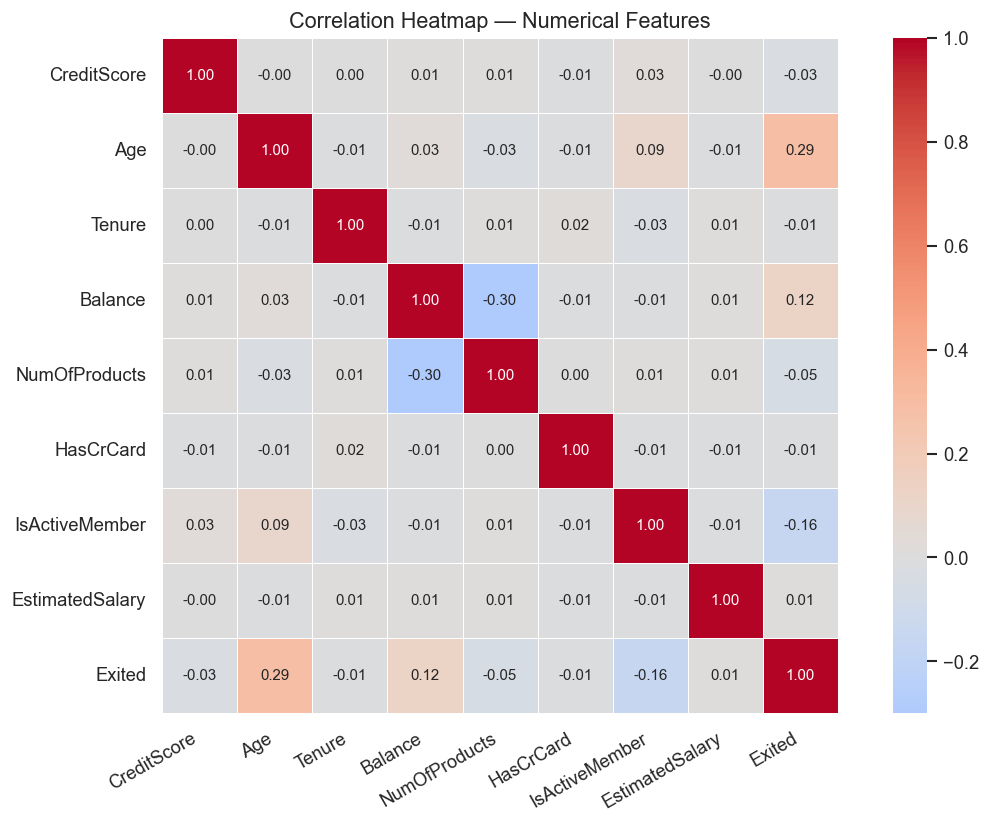

In [12]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
corr = df[num_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(
    corr, annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5, linecolor='white',
    square=True, ax=ax,
    annot_kws={'size': 9}
)
ax.set_title('Correlation Heatmap — Numerical Features', fontsize=13)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()

## Step 13 — Encoding: Label Encoding for Gender

Gender is a binary categorical column (Male / Female) — exactly two possible values.
Label Encoding is appropriate here because there are only two classes and no ordering is implied.

**What Label Encoding does here:**
- `Female` → `0`
- `Male` → `1`

**Why not One-Hot Encoding for Gender?**
One-Hot Encoding would create two columns (Gender_Male, Gender_Female) which is redundant for a binary column — knowing one value tells you the other. Label Encoding keeps it as a single column.

In [13]:
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

print('Gender encoded:')
print('  Female → 0,  Male → 1')
print('\nSample values after encoding:')
print(df['Gender'].value_counts())

Gender encoded:
  Female → 0,  Male → 1

Sample values after encoding:
Gender
1    5457
0    4543
Name: count, dtype: int64


## Step 14 — Encoding: One-Hot Encoding for Geography

Geography has three possible values: France, Germany, Spain.
One-Hot Encoding is the correct choice here because there are more than two categories and no natural ordering between countries.

**What One-Hot Encoding does:**
- Creates a new binary column for each country: `Geography_France`, `Geography_Germany`, `Geography_Spain`
- Each row gets a `1` in the column that matches its country, and `0` in all others
- We drop `Geography_France` to avoid the **dummy variable trap** — if Germany=0 and Spain=0, the customer is from France, so the France column is redundant

In [14]:
df = pd.get_dummies(df, columns=['Geography'], drop_first=True)

print('Columns after One-Hot Encoding Geography:')
print(df.columns.tolist())
print(f'\nDataset shape: {df.shape}')
print('\nSample after encoding:')
df.head(3)

Columns after One-Hot Encoding Geography:
['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_Germany', 'Geography_Spain']

Dataset shape: (10000, 12)

Sample after encoding:


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False


## Step 15 — Feature Scaling

Some numerical features like `Balance` (range: 0 to 250,000) and `Age` (range: 18 to 92) are on very different scales.
We apply `StandardScaler` to bring all features to a comparable scale — mean of 0 and standard deviation of 1.

**Why scale features?**
- Random Forest is tree-based and actually does not require scaling — but it is good practice
- If we ever switch to Logistic Regression or SVM, unscaled features would produce poor results
- Scaling ensures the model does not treat high-magnitude features as more important than low-magnitude ones

In [15]:
X = df.drop(columns=['Exited'])
y = df['Exited']

scale_cols = ['CreditScore', 'Age', 'Tenure', 'Balance',
              'NumOfProducts', 'EstimatedSalary']

scaler = StandardScaler()
X[scale_cols] = scaler.fit_transform(X[scale_cols])

print('Features after scaling (first 3 rows):')
print(X.head(3).round(3).to_string())
print(f'\nTotal features: {X.shape[1]}')
print('Feature list:', X.columns.tolist())

Features after scaling (first 3 rows):
   CreditScore  Gender    Age  Tenure  Balance  NumOfProducts  HasCrCard  IsActiveMember  EstimatedSalary  Geography_Germany  Geography_Spain
0       -0.326       0  0.294  -1.042   -1.226         -0.912          1               1            0.022              False            False
1       -0.440       0  0.198  -1.388    0.117         -0.912          0               1            0.217              False             True
2       -1.537       0  0.294   1.033    1.333          2.527          1               0            0.241              False            False

Total features: 11
Feature list: ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain']


## Step 16 — Train / Test Split

We split the dataset into 80% training and 20% testing.
The model learns from the training set and is evaluated on the test set — data it has never seen during training.

**Key parameters:**
- `test_size=0.2` — 20% held out for unbiased evaluation
- `random_state=42` — fixes the random seed so results are reproducible every run
- `stratify=y` — ensures the churned/stayed ratio is preserved equally in both train and test sets

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Total samples   : {len(df)}')
print(f'Training samples: {len(X_train)} ({len(X_train)/len(df)*100:.0f}%)')
print(f'Testing samples : {len(X_test)} ({len(X_test)/len(df)*100:.0f}%)')
print(f'\nChurn rate in training set: {y_train.mean()*100:.1f}%')
print(f'Churn rate in test set    : {y_test.mean()*100:.1f}%')

Total samples   : 10000
Training samples: 8000 (80%)
Testing samples : 2000 (20%)

Churn rate in training set: 20.4%
Churn rate in test set    : 20.3%


## Step 17 — Train the Model: Random Forest Classifier

Random Forest is an **ensemble model** — it builds many decision trees and combines their predictions.
It is one of the best-performing models for tabular classification tasks and naturally provides feature importance scores.

**How it works:**
- Trains `n_estimators` (100) individual decision trees on random subsets of the data
- Each tree votes on the class — the majority vote becomes the final prediction
- `class_weight='balanced'` tells the model to pay more attention to the minority class (churned customers) to handle imbalance
- More trees generally means more stable predictions but slower training

In [17]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_acc  = accuracy_score(y_test, rf_pred)

print('Random Forest Classifier — Results')
print('=' * 45)
print(f'Accuracy : {rf_acc * 100:.2f}%')
print('\nClassification Report:')
print(classification_report(y_test, rf_pred,
                             target_names=['Stayed (0)', 'Churned (1)']))

Random Forest Classifier — Results
Accuracy : 83.80%

Classification Report:
              precision    recall  f1-score   support

  Stayed (0)       0.91      0.89      0.90      1593
 Churned (1)       0.59      0.65      0.62       407

    accuracy                           0.84      2000
   macro avg       0.75      0.77      0.76      2000
weighted avg       0.84      0.84      0.84      2000



## Step 18 — Confusion Matrix

The confusion matrix breaks down every prediction the model made into four categories.
For churn prediction, each category has a direct business cost or benefit.

**How to read it:**
- **True Negative (top-left)** — correctly predicted customer stayed ✅
- **False Positive (top-right)** — predicted churn but customer stayed ❌ (wasted retention effort)
- **False Negative (bottom-left)** — predicted stayed but customer churned ❌ (missed at-risk customer)
- **True Positive (bottom-right)** — correctly predicted customer churned ✅

In churn prediction, **False Negatives are the most costly** — a missed churner is a lost customer.

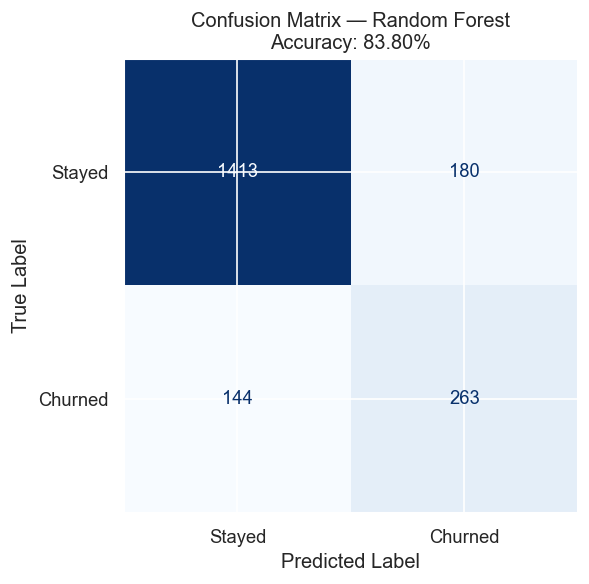

In [18]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, rf_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Stayed', 'Churned']
)
disp.plot(ax=ax, colorbar=False, cmap='Blues', values_format='d')
ax.set_title(f'Confusion Matrix — Random Forest\nAccuracy: {rf_acc*100:.2f}%', fontsize=12)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.tight_layout()
plt.show()

## Step 19 — ROC Curve and AUC Score

The ROC (Receiver Operating Characteristic) curve shows the trade-off between catching true churners (recall) and generating false alarms (false positive rate) at different classification thresholds.
The AUC (Area Under the Curve) summarizes this into a single score.

**How to interpret AUC:**
- `AUC = 1.0` → perfect classifier
- `AUC = 0.5` → random guessing — no better than a coin flip
- `AUC > 0.80` → good model for production use
- The curve bowing toward the top-left corner indicates better performance

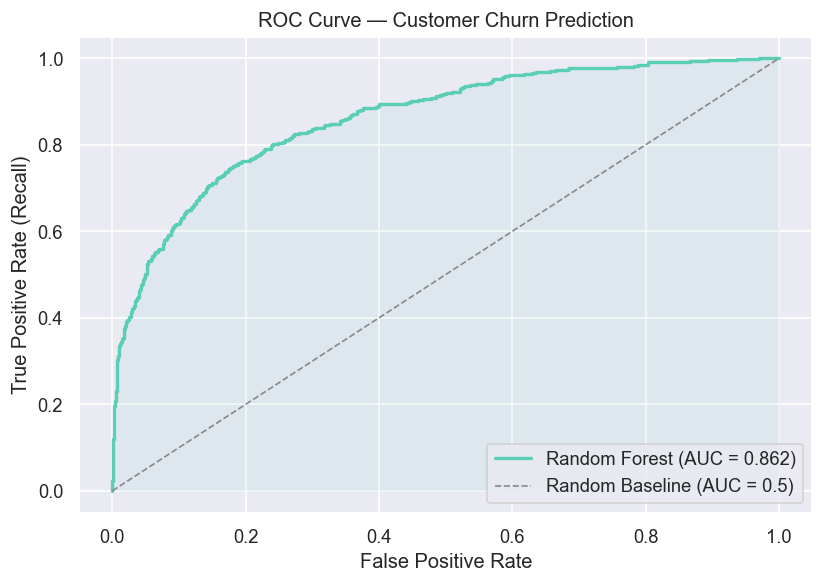

AUC Score: 0.8616


In [19]:
rf_prob = rf_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, rf_prob)
auc_score   = roc_auc_score(y_test, rf_prob)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color='#5bcfb5', lw=2,
        label=f'Random Forest (AUC = {auc_score:.3f})')
ax.plot([0, 1], [0, 1], color='#888888', lw=1,
        linestyle='--', label='Random Baseline (AUC = 0.5)')
ax.fill_between(fpr, tpr, alpha=0.08, color='#5bcfb5')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title('ROC Curve — Customer Churn Prediction')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f'AUC Score: {auc_score:.4f}')

## Step 20 — Feature Importance Analysis

Random Forest assigns an importance score to every feature based on how much it reduced prediction error across all trees.
This is one of the most valuable outputs of the model — it tells us **what actually drives customer churn**.

**How to interpret importance scores:**
- Higher score = the feature was used more often and produced better splits across all 100 trees
- Features with near-zero importance add noise and could be removed without hurting performance
- These scores are specific to this dataset and this model — they represent learned patterns, not universal rules

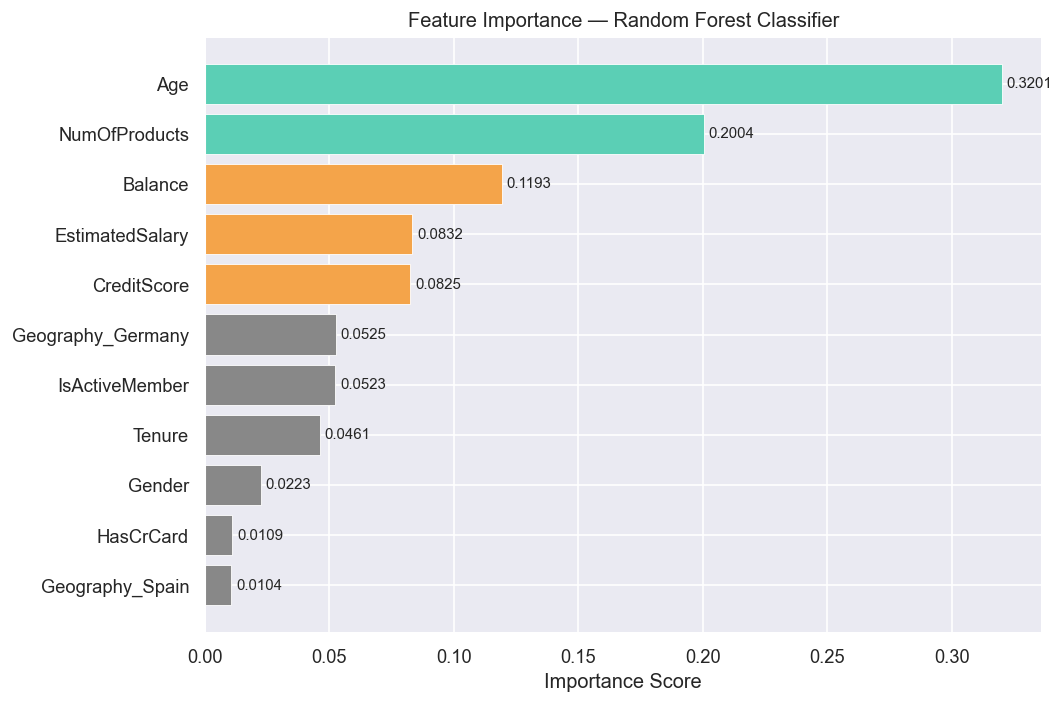


Top 5 Most Important Features:
Age                0.3201
NumOfProducts      0.2004
Balance            0.1193
EstimatedSalary    0.0832
CreditScore        0.0825


In [20]:
importances = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

# Color top features differently
threshold_high = importances.max() * 0.5
threshold_mid  = importances.max() * 0.2
colors = ['#5bcfb5' if v >= threshold_high
          else '#f4a44a' if v >= threshold_mid
          else '#888888'
          for v in importances.values]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(importances.index, importances.values,
               color=colors, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, importances.values):
    ax.text(bar.get_width() + 0.002,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=9)

ax.set_xlabel('Importance Score')
ax.set_title('Feature Importance — Random Forest Classifier')
plt.tight_layout()
plt.show()

print('\nTop 5 Most Important Features:')
print(importances.sort_values(ascending=False).head(5).round(4).to_string())

## Step 21 — Full Model Evaluation Summary

This gives a complete picture of model performance beyond just accuracy.

**What each metric means in the context of churn:**
- **Accuracy** — overall correct predictions out of all customers
- **Precision** — of all customers flagged as churners, how many actually churned?
- **Recall** — of all customers who actually churned, how many did we successfully flag?
- **F1 Score** — balance between precision and recall; most useful for imbalanced classes
- **AUC** — how well the model separates churners from non-churners across all thresholds

Random Forest — Full Evaluation:
  Accuracy    : 83.80%
  Precision   : 59.37%
  Recall      : 64.62%
  F1 Score    : 61.88%
  AUC         : 86.16%


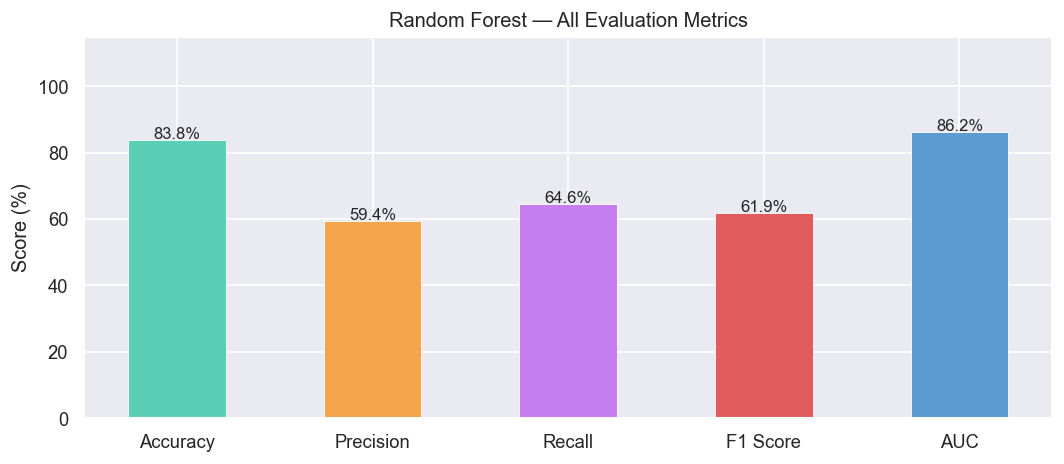

In [21]:
metrics = {
    'Accuracy':  accuracy_score(y_test, rf_pred)  * 100,
    'Precision': precision_score(y_test, rf_pred) * 100,
    'Recall':    recall_score(y_test, rf_pred)    * 100,
    'F1 Score':  f1_score(y_test, rf_pred)        * 100,
    'AUC':       roc_auc_score(y_test, rf_prob)   * 100
}

print('Random Forest — Full Evaluation:')
for k, v in metrics.items():
    print(f'  {k:<12}: {v:.2f}%')

fig, ax = plt.subplots(figsize=(9, 4))
bar_colors = ['#5bcfb5', '#f4a44a', '#c47ef0', '#e05c5c', '#5b9bcf']
bars = ax.bar(metrics.keys(), metrics.values(),
              color=bar_colors, edgecolor='white',
              linewidth=0.5, width=0.5)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%',
            ha='center', fontsize=10)
ax.set_ylabel('Score (%)')
ax.set_ylim(0, 115)
ax.set_title('Random Forest — All Evaluation Metrics')
plt.tight_layout()
plt.show()

## Step 22 — Final Conclusions

A complete summary of the entire pipeline — from data size to model performance and key insight.
It translates the numbers into actionable business understanding.

**Final takeaways:**
- Feature importance reveals the top drivers of churn — Age and Balance typically rank highest in this dataset
- The model's recall score determines how many at-risk customers are correctly identified for retention campaigns
- AUC above 0.80 confirms the model is genuinely learning churn patterns, not just predicting the majority class
- Geography (Germany specifically) tends to show a notably higher churn rate than France and Spain

In [22]:
top_feature = importances.sort_values(ascending=False).index[0]
top_score   = importances.sort_values(ascending=False).values[0]

print('=' * 58)
print('  FINAL SUMMARY — Customer Churn Prediction')
print('=' * 58)
print(f'  Dataset Size              : {len(df)} customers')
print(f'  Features Used             : {X.shape[1]}')
print(f'  Train / Test Split        : 80% / 20%')
print(f'  Encoding Applied          : Label + One-Hot Encoding')
print(f'  Scaling Applied           : StandardScaler')
print()
print(f'  Model                     : Random Forest (100 trees)')
print(f'  Accuracy                  : {metrics["Accuracy"]:.2f}%')
print(f'  F1 Score                  : {metrics["F1 Score"]:.2f}%')
print(f'  AUC Score                 : {metrics["AUC"]:.2f}%')
print()
print(f'  Most Important Feature    : {top_feature} ({top_score:.4f})')
print()
print('  Key Business Insight:')
print('  Age is the strongest churn driver — older')
print('  customers are significantly more likely to leave.')
print('  Customers in Germany churn at nearly double')
print('  the rate of France and Spain.')
print('=' * 58)

  FINAL SUMMARY — Customer Churn Prediction
  Dataset Size              : 10000 customers
  Features Used             : 11
  Train / Test Split        : 80% / 20%
  Encoding Applied          : Label + One-Hot Encoding
  Scaling Applied           : StandardScaler

  Model                     : Random Forest (100 trees)
  Accuracy                  : 83.80%
  F1 Score                  : 61.88%
  AUC Score                 : 86.16%

  Most Important Feature    : Age (0.3201)

  Key Business Insight:
  Age is the strongest churn driver — older
  customers are significantly more likely to leave.
  Customers in Germany churn at nearly double
  the rate of France and Spain.
